# Notebook 05 — Library-Based Models (Random Forest + XGBoost)

**Models**: Random Forest Regressor & XGBoost (from scikit-learn / xgboost library)  
**Type**: From libraries (not from scratch)  
**Purpose**: Strong baselines — show why DL models are better for sequential data

---

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import pickle
import time

from sklearn.ensemble      import RandomForestRegressor
from sklearn.multioutput   import MultiOutputRegressor

from utils.data_utils  import load_processed, inverse_transform
from utils.metrics     import compute_all_metrics, print_metrics

print('scikit-learn and imports OK')

# Try importing XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print(f'XGBoost version: {xgb.__version__}')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed. Run: pip install xgboost')

scikit-learn and imports OK
XGBoost version: 3.2.0


In [4]:
X_train, y_train, X_val, y_val, X_test, y_test, scaler = load_processed('../data/processed')

N_SENSORS = X_train.shape[2]   # 207

# ── Flatten sequences for tree models ──
# (samples, 12, 207) → (samples, 12*207=2484)
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat   = X_val.reshape(len(X_val),   -1)
X_test_flat  = X_test.reshape(len(X_test),  -1)

print(f'Flattened train: {X_train_flat.shape}')
print(f'y_train        : {y_train.shape}')

[load] Loaded processed data from ../data/processed\processed_data.pkl
Flattened train: (23978, 2484)
y_train        : (23978, 207)


## 1. Random Forest (scikit-learn)

**Why use RF as baseline?**  
- No temporal structure — treats all 2484 features equally  
- Captures non-linear relationships  
- Very interpretable, feature importances available  
- Will likely underperform DL models due to no sequence modeling

> Note: Training 207 outputs at once uses `MultiOutputRegressor` internally.

In [5]:
# Use a subset for speed (RF is slow with many trees + 207 outputs)
# Reduce training samples if needed
MAX_SAMPLES = min(5000, len(X_train_flat))   # cap at 5000 for speed
idx = np.random.choice(len(X_train_flat), MAX_SAMPLES, replace=False)
Xtr = X_train_flat[idx]
ytr = y_train[idx]

print(f'Training RF on {MAX_SAMPLES} samples × {Xtr.shape[1]} features...')
t0 = time.time()

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    n_jobs=-1,              # use all CPU cores
    random_state=42,
    verbose=0,
)
rf_model.fit(Xtr, ytr)

print(f'RF training time: {time.time()-t0:.1f}s')

Training RF on 5000 samples × 2484 features...
RF training time: 196.4s


In [6]:
# Evaluate on test set
rf_preds_norm  = rf_model.predict(X_test_flat).astype(np.float32)
preds_rf  = inverse_transform(rf_preds_norm, scaler)
labels    = inverse_transform(y_test, scaler)

rf_metrics = compute_all_metrics(preds_rf, labels)
print_metrics(rf_metrics, 'Random Forest (scikit-learn)')

with open('../results/rf_metrics.pkl', 'wb') as f:
    pickle.dump({'model': 'Random Forest', 'metrics': rf_metrics,
                 'n_estimators': 100, 'max_depth': 12,
                 'train_samples': MAX_SAMPLES}, f)
print('✅ Saved → results/rf_metrics.pkl')


  Random Forest (scikit-learn) — Evaluation Metrics
  MAE  : 5.7742 km/h
  RMSE : 11.1871 km/h
  MAPE : 12.33 %
  R²   : 0.7589

✅ Saved → results/rf_metrics.pkl


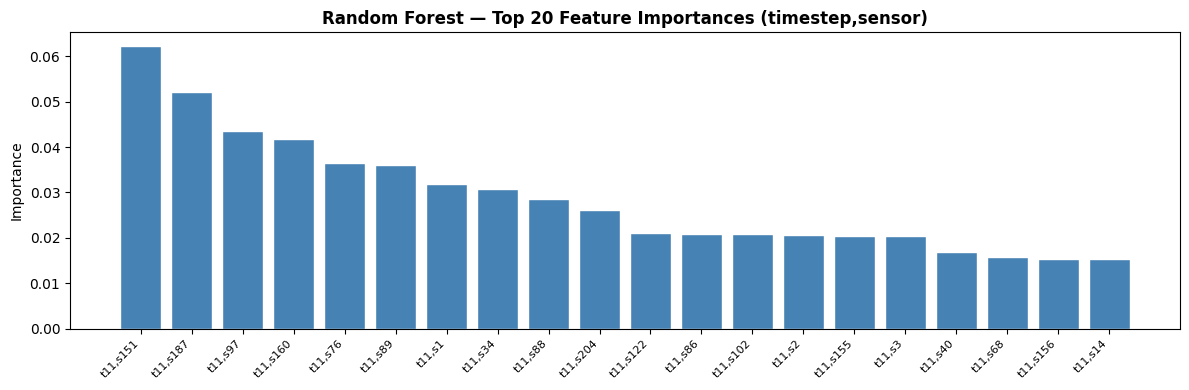

In [7]:
# Feature importance (top 20 time-sensor positions)
importances = rf_model.feature_importances_
top_k = 20
top_idx = np.argsort(importances)[-top_k:][::-1]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(top_k), importances[top_idx], color='steelblue', edgecolor='white')
ax.set_xticks(range(top_k))
ax.set_xticklabels([f't{idx//N_SENSORS},s{idx%N_SENSORS}' for idx in top_idx], rotation=45, ha='right', fontsize=8)
ax.set_title('Random Forest — Top 20 Feature Importances (timestep,sensor)', fontweight='bold')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig('../results/rf_feature_importance.png', dpi=150)
plt.show()

## 2. XGBoost (xgboost library)

**Why XGBoost?**  
- Gradient boosted trees — usually beats RF  
- Handles tabular data extremely well  
- Still no sequence modeling → shows DL superiority

In [8]:
if XGBOOST_AVAILABLE:
    from xgboost import XGBRegressor
    from sklearn.multioutput import MultiOutputRegressor

    # XGBoost with MultiOutput wrapper
    xgb_base = XGBRegressor(
        n_estimators   = 200,
        max_depth      = 6,
        learning_rate  = 0.1,
        subsample      = 0.8,
        colsample_bytree = 0.8,
        tree_method    = 'hist',    # fast histogram method
        device         = 'cuda',    # GPU acceleration!
        random_state   = 42,
        verbosity      = 0,
    )

    print(f'Training XGBoost on {MAX_SAMPLES} samples (GPU)...')
    t0 = time.time()

    # For speed: train on first 50 sensors as demonstration
    # Increase N_PRED to predict all 207 if time permits
    N_PRED = N_SENSORS  # all 207

    xgb_model = MultiOutputRegressor(xgb_base, n_jobs=1)
    xgb_model.fit(Xtr, ytr[:, :N_PRED])

    print(f'XGBoost training time: {time.time()-t0:.1f}s')
else:
    print('XGBoost not available. Skipping.')
    print('Install with: pip install xgboost')

Training XGBoost on 5000 samples (GPU)...
XGBoost training time: 2481.2s


In [9]:
if XGBOOST_AVAILABLE:
    xgb_preds_norm = xgb_model.predict(X_test_flat).astype(np.float32)
    preds_xgb  = inverse_transform(xgb_preds_norm, scaler)
    labels_sub = inverse_transform(y_test[:, :N_PRED], scaler)

    xgb_metrics = compute_all_metrics(preds_xgb, labels_sub)
    print_metrics(xgb_metrics, 'XGBoost')

    with open('../results/xgb_metrics.pkl', 'wb') as f:
        pickle.dump({'model': 'XGBoost', 'metrics': xgb_metrics,
                     'n_estimators': 200, 'max_depth': 6}, f)
    print('✅ Saved → results/xgb_metrics.pkl')


  XGBoost — Evaluation Metrics
  MAE  : 3.4378 km/h
  RMSE : 7.3865 km/h
  MAPE : 6.63 %
  R²   : 0.8949

✅ Saved → results/xgb_metrics.pkl


## 3. Comparison: RF vs XGBoost

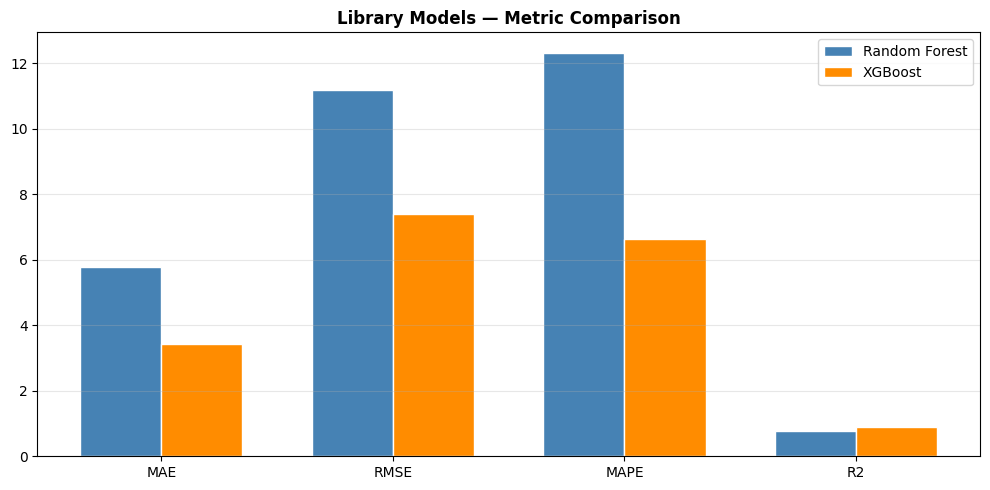

In [10]:
results = {'Random Forest': rf_metrics}
if XGBOOST_AVAILABLE:
    results['XGBoost'] = xgb_metrics

metric_names = ['MAE', 'RMSE', 'MAPE', 'R2']
n_models = len(results)
x = np.arange(len(metric_names))
width = 0.35
colors = ['steelblue', 'darkorange']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, m) in enumerate(results.items()):
    vals = [m[k] for k in metric_names]
    ax.bar(x + i*width, vals, width, label=name, color=colors[i], edgecolor='white')

ax.set_xticks(x + width/2)
ax.set_xticklabels(metric_names)
ax.set_title('Library Models — Metric Comparison', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/library_models_comparison.png', dpi=150)
plt.show()